<a href="https://colab.research.google.com/github/xoxoreyniel/DSC1107/blob/main/DSC1107_FA4_Awit%2C_JT%3B_Deloyola%2C_JR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Install libraries

In [2]:
library(tidyverse)

# This is the direct CSV link provided in your instructions
adult_raw <- read.csv("/content/adultTrain.csv")

# This handles the '?' values mentioned in Part 1
adult_raw <- adult_raw %>%
  mutate(across(where(is.character), ~na_if(., "?")))

Tidy & Explore

In [3]:
library(tidyverse)

# 1. Handle '?' entries and convert categorical to factors
adult_clean <- adult_raw %>%
  mutate(across(where(is.character), ~na_if(., "?"))) %>%
  drop_na() %>%
  mutate(across(where(is.character), as.factor))

# 2. Display structure and summary
glimpse(adult_clean)
summary(adult_clean)

Rows: 30,162
Columns: 15
$ age            <int> 39, 50, 38, 53, 28, 37, 49, 52, 31, 42, 37, 30, 23, 32,…
$ workclass      <fct> State-gov, Self-emp-not-inc, Private, Private, Private,…
$ fnlwgt         <int> 77516, 83311, 215646, 234721, 338409, 284582, 160187, 2…
$ education      <fct> Bachelors, Bachelors, HS-grad, 11th, Bachelors, Masters…
$ education_num  <int> 13, 13, 9, 7, 13, 14, 5, 9, 14, 13, 10, 13, 13, 12, 4, …
$ marital_status <fct> Never-married, Married-civ-spouse, Divorced, Married-ci…
$ occupation     <fct> Adm-clerical, Exec-managerial, Handlers-cleaners, Handl…
$ relationship   <fct> Not-in-family, Husband, Not-in-family, Husband, Wife, W…
$ race           <fct> White, White, White, Black, Black, White, Black, White,…
$ sex            <fct> Male, Male, Male, Male, Female, Female, Female, Male, F…
$ capital_gain   <int> 2174, 0, 0, 0, 0, 0, 0, 0, 14084, 5178, 0, 0, 0, 0, 0, …
$ capital_loss   <int> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ hours_per_wee

      age                   workclass         fnlwgt               education   
 Min.   :17.00   Federal-gov     :  943   Min.   :  13769   HS-grad     :9840  
 1st Qu.:28.00   Local-gov       : 2067   1st Qu.: 117627   Some-college:6678  
 Median :37.00   Private         :22286   Median : 178425   Bachelors   :5044  
 Mean   :38.44   Self-emp-inc    : 1074   Mean   : 189794   Masters     :1627  
 3rd Qu.:47.00   Self-emp-not-inc: 2499   3rd Qu.: 237628   Assoc-voc   :1307  
 Max.   :90.00   State-gov       : 1279   Max.   :1484705   11th        :1048  
                 Without-pay     :   14                     (Other)     :4618  
 education_num                 marital_status            occupation  
 Min.   : 1.00   Divorced             : 4214   Prof-specialty :4038  
 1st Qu.: 9.00   Married-AF-spouse    :   21   Craft-repair   :4030  
 Median :10.00   Married-civ-spouse   :14065   Exec-managerial:3992  
 Mean   :10.12   Married-spouse-absent:  370   Adm-clerical   :3721  
 3rd Qu.:1

Part 2: Logistic Regression

In [5]:
# 1. Fit logistic regression predicting income
logit_mod <- glm(class ~ ., data = adult_clean, family = "binomial")

# 2. Identify significant predictors
summary(logit_mod)

# 3. Compute accuracy (0.5 threshold)
probs <- predict(logit_mod, type = "response")
preds <- ifelse(probs > 0.5, 1, 0)
# Adjust 'actuals' mapping to match your factor levels (usually 0 for <=50K, 1 for >50K)
actuals <- ifelse(adult_clean$class == ">50K", 1, 0)

accuracy <- mean(preds == actuals)
cat("Classification Accuracy:", round(accuracy, 4))

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”



Call:
glm(formula = class ~ ., family = "binomial", data = adult_clean)

Coefficients: (1 not defined because of singularities)
                                           Estimate Std. Error z value Pr(>|z|)
(Intercept)                              -6.408e+00  7.636e-01  -8.392  < 2e-16
age                                       2.550e-02  1.712e-03  14.890  < 2e-16
workclassLocal-gov                       -6.985e-01  1.130e-01  -6.184 6.26e-10
workclassPrivate                         -5.055e-01  9.379e-02  -5.390 7.06e-08
workclassSelf-emp-inc                    -3.293e-01  1.239e-01  -2.658 0.007857
workclassSelf-emp-not-inc                -9.972e-01  1.100e-01  -9.063  < 2e-16
workclassState-gov                       -8.207e-01  1.254e-01  -6.544 6.00e-11
workclassWithout-pay                     -1.329e+01  1.972e+02  -0.067 0.946265
fnlwgt                                    7.515e-07  1.762e-07   4.264 2.01e-05
education11th                             9.462e-02  2.139e-01   0.442 

Classification Accuracy: 0.8498

Part 3: Regression in High Dimensions

In [8]:
# 1. One-hot encoding (creating dummy variables)
# We use class ~ . - 1 to exclude the intercept from the matrix
adult_hd_matrix <- model.matrix(class ~ . - 1, data = adult_clean)
adult_hd <- as.data.frame(adult_hd_matrix)
adult_hd$class <- adult_clean$class # Renaming the column to 'class' to match the original data frame

# 2. Report n and p
n_obs <- nrow(adult_hd)
p_preds <- ncol(adult_hd) - 1 # subtracting 1 for the target 'class'
cat("n =", n_obs, "| p =", p_preds)

n = 30162 | p = 97

Interpretation: This dataset is considered high-dimensional because $p$ (number of predictors) has grown significantly due to one-line encoding. This can lead to multicollinearity, where predictors are highly correlated, causing standard regression coefficients to become unstable or causing the model to overfit the noise in the training data.

Part 4: Ridge and Lasso Regression

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘iterators’, ‘foreach’, ‘shape’, ‘RcppEigen’


Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loaded glmnet 4.1-10



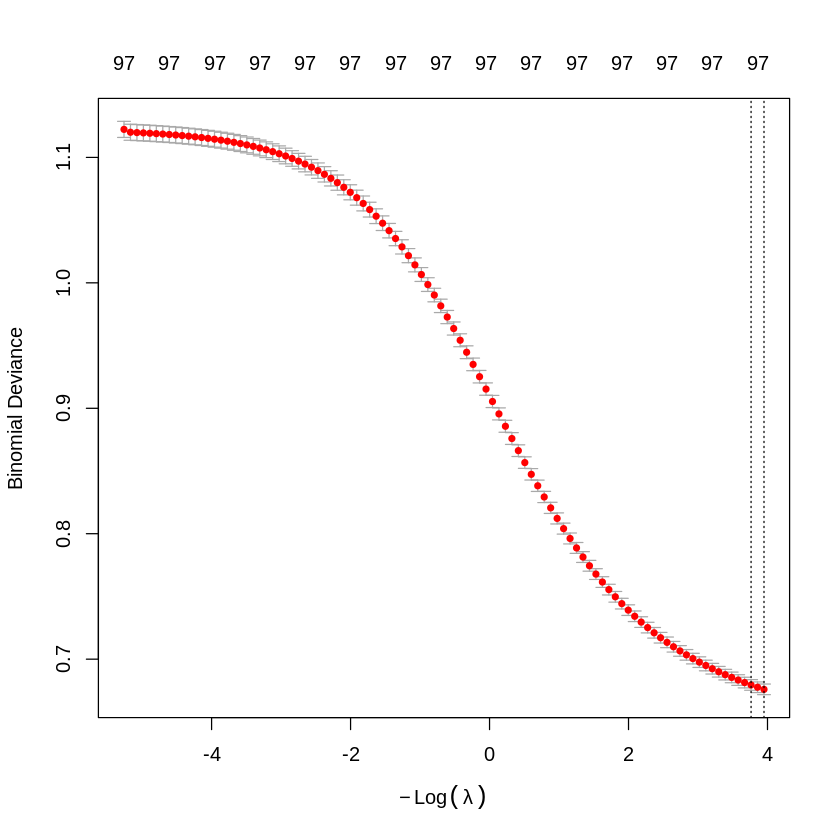

Variables retained by Lasso: 82

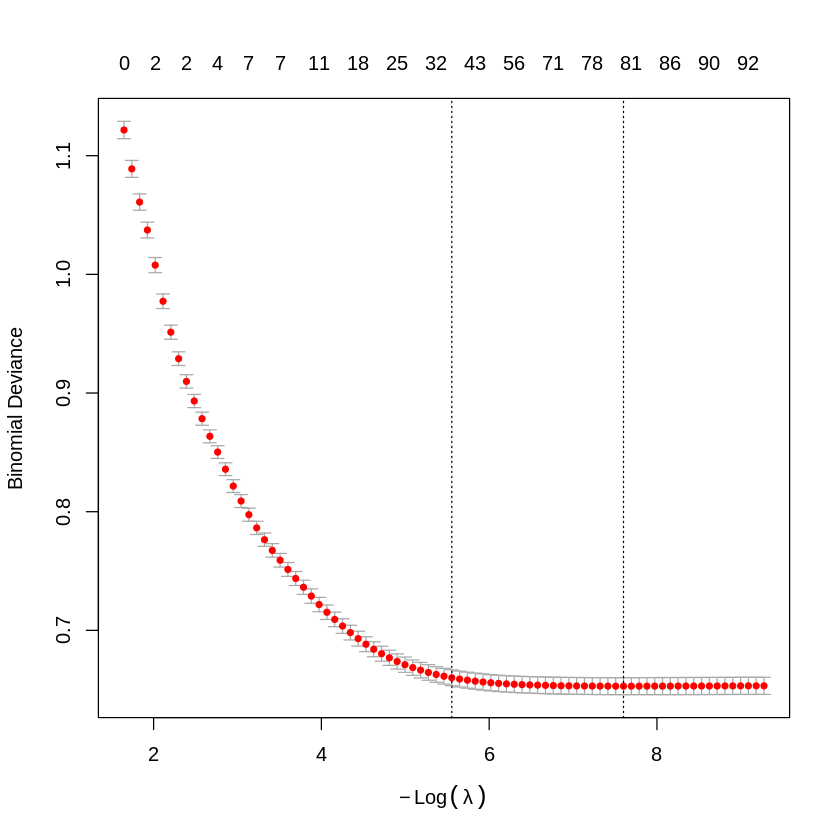

In [10]:
install.packages("glmnet")
library(glmnet)

# Prepare matrices for glmnet
x <- adult_hd_matrix
y <- adult_clean$class # Corrected: using 'class' instead of 'income'

# 1. Ridge Regression (alpha = 0) with CV
cv_ridge <- cv.glmnet(x, y, family = "binomial", alpha = 0)
plot(cv_ridge)

# 2. Lasso Regression (alpha = 1) with CV
cv_lasso <- cv.glmnet(x, y, family = "binomial", alpha = 1)
plot(cv_lasso)

# 3. Identify retained variables in Lasso (non-zero coefficients)
lasso_coefs <- coef(cv_lasso, s = "lambda.min")
retained_count <- sum(lasso_coefs != 0) - 1 # exclude intercept
cat("Variables retained by Lasso:", retained_count)

Part 5: Decision Tree

Comparison: Ridge regression addresses multicollinearity by shrinking all coefficients toward zero, which reduces variance but keeps all variables in the model. Lasso regression goes further by forcing some coefficients to exactly zero, effectively performing variable selection and simplifying the model.

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



  relationship marital_status   capital_gain      education  education_num 
    2277.27804     2241.64682      972.70339      900.05753      900.05753 
           sex     occupation            age hours_per_week native_country 
     746.44935      672.96544      520.51131      313.94878       24.29071 
  capital_loss 
      16.04922 


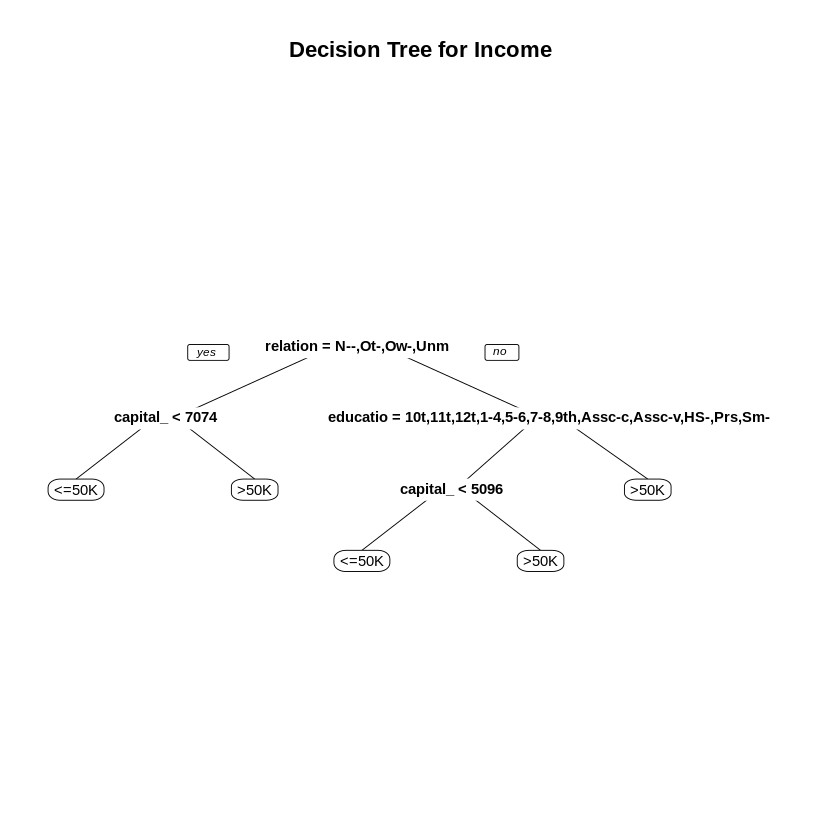

In [13]:
library(rpart)
install.packages("rpart.plot")
library(rpart.plot)

# 1. Grow the tree
tree_mod <- rpart(class ~ ., data = adult_clean, method = "class")

# 2. Visualize the tree
prp(tree_mod, main="Decision Tree for Income")

# 3. Pruning using cross-validation
# Finding the CP value that minimizes cross-validation error
best_cp <- tree_mod$cptable[which.min(tree_mod$cptable[,"xerror"])[1],"CP"]
pruned_tree <- prune(tree_mod, cp = best_cp)

# 4. Identify most important predictors
# The top nodes in the visualization are usually the most important
# Alternatively, use: tree_mod$variable.importance
print(tree_mod$variable.importance)

Part 6: Bagging

In [18]:
install.packages("randomForest")
library(randomForest)

# 1. Implement Bagging (mtry = total number of predictors)
# Using a subset or reducing ntree if your computer is slow
bag_mod <- randomForest(class ~ ., data = adult_clean, mtry = (ncol(adult_clean)-1), importance = TRUE)

# 2. Compare performance
# Compare the Out-of-Bag (OOB) error of Bagging vs the error of a single tree
print(bag_mod)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)




Call:
 randomForest(formula = class ~ ., data = adult_clean, mtry = (ncol(adult_clean) -      1), importance = TRUE) 
               Type of random forest: classification
                     Number of trees: 500
No. of variables tried at each split: 14

        OOB estimate of  error rate: 14.87%
Confusion matrix:
      <=50K >50K class.error
<=50K 20754 1900   0.0838704
>50K   2584 4924   0.3441662


A single decision tree has high variance, it changes drastically with small changes in the data.
\n Bagging (Bootstrap Aggregation) creates many trees from different samples and averages them.
\n This cancels out individual errors, leading to a much more stable and accurate model.